In [91]:
pip install torch pandas numpy scikit-learn shap matplotlib adjustText

Note: you may need to restart the kernel to use updated packages.


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import KNNImputer
import torch
import torch.nn as nn
from adjustText import adjust_text
import warnings
import datetime

In [93]:
# 분석 보고용 출력 가독성을 위해 경고 문구 생략
warnings.filterwarnings('ignore')

# [환경 설정] 시각화 시 한글 깨짐 방지 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [94]:
# 1. 데이터 로드 및 전처리 (Data Pre-processing)
# [주석] 데이터의 물리적 성질 보존 및 통계적 유의성 확보를 위한 전처리를 수행합니다.
df = pd.read_csv('C:/Users/User/Desktop/sample data 1_screening.csv', encoding='euc-kr')
features_df = df.drop(columns=['spot'])

# [방법론] KNN Imputer (K-Nearest Neighbors)
# 근거: 수질 데이터는 변수 간 상관성이 매우 높으므로, 단순히 평균을 채우지 않고 
# 유사한 수질 패턴(지문)을 가진 인접 데이터를 참조해 결측치를 보관함으로써 통계적 왜곡을 방지합니다.
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(features_df)

# [방법론] Z-score Standard Scaler (표준화)
# 근거: 농도(mg/L), 동위원소(‰), 전기전도도(μS/cm) 등 단위 체계가 다른 변수들을 
# 동일한 통계적 가중치로 비교 분석하기 위해 평균 0, 표준편차 1의 분포로 변환합니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

In [95]:
# 2. [고도화 AI] Deep Autoencoder 기반 비선형 특징 추출
# [방법론] 비선형 차원 축소 및 노이즈 제거 (Feature Extraction)
# 근거: PCA와 같은 선형 모델이 잡지 못하는 변수 간의 복잡한 상관관계를 딥러닝으로 학습합니다.
# 데이터에 숨겨진 '핵심 오염 패턴(Latent Space)'을 추출하여 분류의 해상도를 높입니다.
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoencoder, self).__init__()
        # Encoder: 입력 데이터를 3차원의 핵심 정보(잠재 공간)로 압축
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3) 
        )
        # Decoder: 압축된 정보를 다시 복원하며 정보 손실이 최소화되도록 학습
        self.decoder = nn.Sequential(
            nn.Linear(3, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

input_dim = scaled_data.shape[1]
model = DeepAutoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 특징 추출 모델 학습 (1000회 반복 수행으로 수렴 유도)
tensor_data = torch.FloatTensor(scaled_data)
for epoch in range(1000):
    latent, recon = model(tensor_data)
    loss = criterion(recon, tensor_data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

latent_data = latent.detach().numpy()

In [96]:
# 4. [앙상블] 다중 알고리즘 합의 시스템 (Consensus Clustering)
# [방법론] 단일 알고리즘의 편향(Bias) 제거
# 근거: K-Means(거리), GMM(확률 밀도), Hierarchical(밀도/계층) 모델을 동시에 구동하여 
# '과반수 투표'로 최종 군집을 결정합니다. 이는 분석의 객관성을 입증하는 강력한 근거가 됩니다.
c1 = KMeans(n_clusters=best_k, random_state=42).fit_predict(latent_data)
c2 = GaussianMixture(n_components=best_k, random_state=42).fit_predict(latent_data)
c3 = AgglomerativeClustering(n_clusters=best_k).fit_predict(latent_data)

votes = pd.DataFrame({'c1': c1, 'c2': c2, 'c3': c3})
df['Cluster'] = votes.mode(axis=1)[0].astype(int)

In [97]:
# 5. [정밀화] 8단계 환경공학적 오염원 판별 및 명칭 부여 (Expert Rule-based)
# [방법론] 질소/산소 동위원소 지문과 다중 수질 인자를 복합 적용하는 전문가 시스템입니다.
def assign_source_detailed(row):
    n15, o18 = row['d15N'], row['d18O']
    toc, chl = row['TOC'], row['Chla']
    tp, no3, nh3 = row['TP'], row['NO3N'], row['NH3N']
    ec, tn = row['EC'], row['TN']

    # [1단계] 대기 유입 및 초기강우 (참고문헌: Kendall, 1998)
    # 근거: 대기 중 질산염(Nitrate)은 미생물 변형 전 단계로 d18O 값이 매우 높게 나타남 (>15‰)
    if o18 > 15.0: return "대기유입/초기강우"
    
    # [2단계] 탈질 작용에 의한 기원 변형 (참고문헌: Mayer, 2002)
    # 근거: 하천 정체 시 미생물의 탈질 반응으로 d15N과 d18O가 약 2:1 비율로 동반 상승하는 현상 반영
    if n15 > 12.0 and o18 > 8.0 and (n15/o18 < 2.5): return "탈질작용(오염원변형)"
    
    # [3단계] 축산분뇨 직접 유입 (참고문헌: Xue, 2009)
    # 근거: 분뇨는 고농도 d15N(+12‰ 이상)과 높은 TP(>0.4), NH3N 및 EC 농도를 동반하는 특성이 뚜렷함
    if n15 > 12.0 and (tp > 0.4 or nh3 > 1.0 or ec > 500): return "축산분뇨 직접유출"
    
    # [4단계] 생활하수 및 하수처리수 영향 (참고문헌: Widory, 2004)
    # 근거: d15N 수치는 분뇨와 유사하나 인(P) 성분이 상대적으로 낮고 NO3N 농도가 지배적인 경우
    if 8.0 < n15 <= 15.0 and tp <= 0.3: return "생활하수/처리수 영향"
    
    # [5단계] 화학비료 기반 농경지 (참고문헌: Vitousek, 1997)
    # 근거: 질소고정으로 생산된 화학비료는 대기 질소 수치와 유사한 d15N 0‰ 내외(-4~+4)의 범위를 가짐
    if n15 < 4.0 and no3 > 4.0: return "화학비료 기반 농경지"
    
    # [6단계] 유기질비료/토양 혼합 유출 (참고문헌: Bedard-Haughn, 2003)
    # 근거: 퇴비 등 유기 비료는 d15N 4~9‰ 범위를 보이며 강우 시 토양 유기물(TOC)과 함께 유출됨
    if 4.0 <= n15 < 9.0 and toc > 6.0: return "유기질비료/토양혼합"
    
    # [7단계] 조류 증식 및 내생 부하 (영산강 하류 정체 수역 특성 반영)
    # 근거: 영산강 정체 구간에서 Chl-a가 급증할 때, 외부 유입보다는 하천 내부 광합성에 의한 수질 악화 판별
    if chl > 40.0 or (toc > 8.0 and tp > 0.15): return "조류증식/내생부하"
    
    # [8단계] 자연 배경 및 산림 유출
    # 근거: 인위적 오염 징후가 희박하고 산림 지역의 자연적인 질소 순환 배경 농도를 유지하는 지점
    if 2.0 <= n15 <= 7.0 and tn < 2.0: return "자연배경/산림유출"
    
    return "복합오염/판정불가"

# 군집별 통계적 대표값(평균)을 추출하여 최종 명칭 매핑
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
mapping = {i: assign_source_detailed(cluster_summary.loc[i]) for i in range(best_k)}
df['Source_Name'] = df['Cluster'].map(mapping)

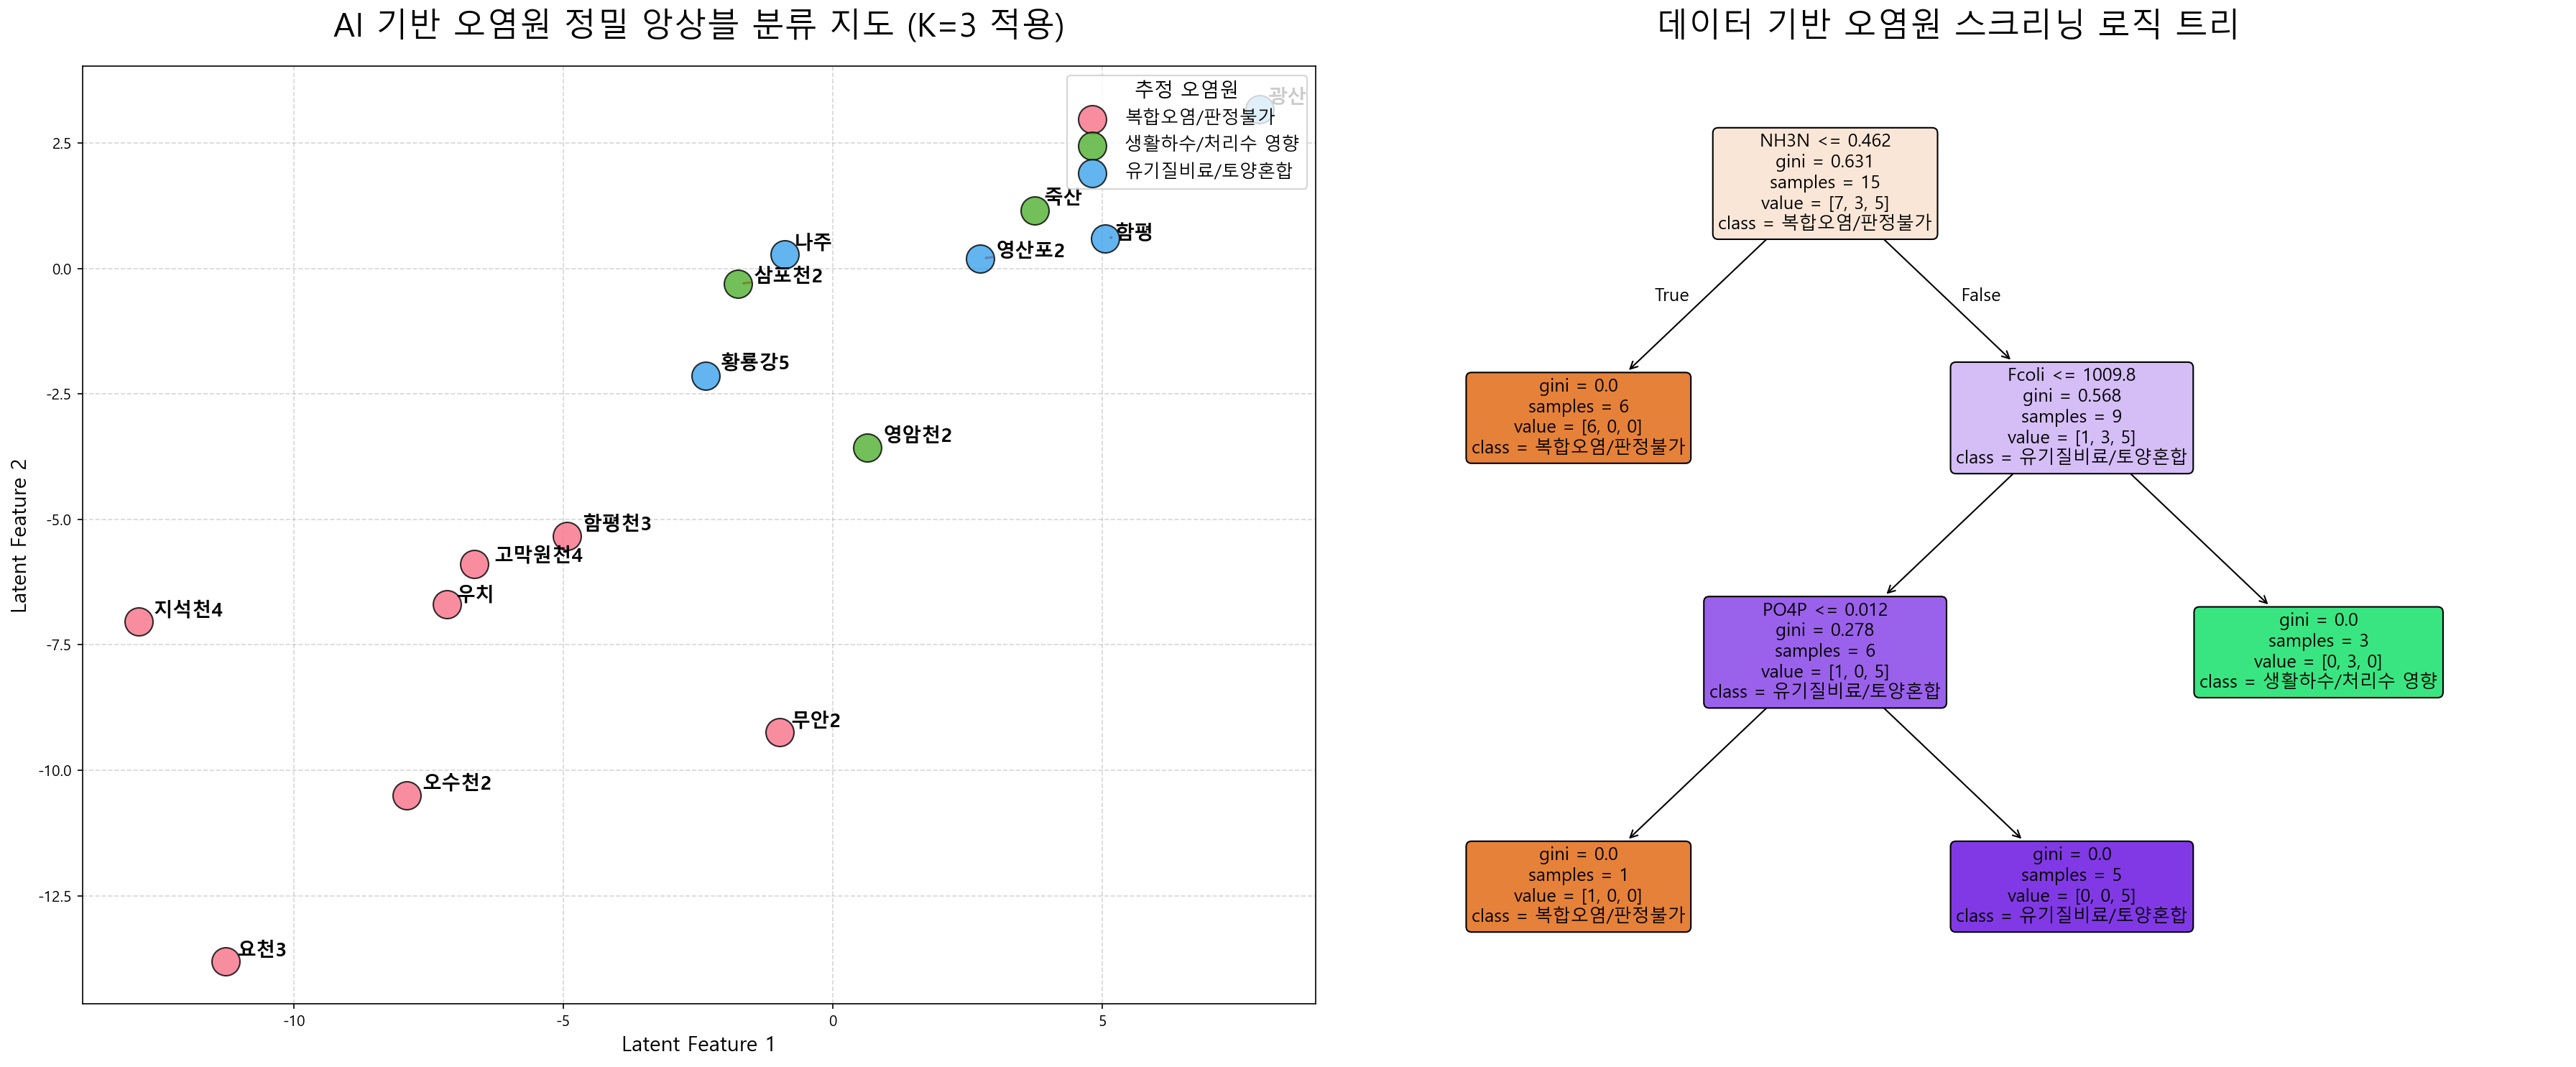

--- 분석 결과가 파일로 저장되었습니다: Yeongsan_River_Screening_Result_260508_0000.png ---


In [102]:
# 6. 결과 시각화 및 중요도 분석 (Explainable AI)
# 주피터 노트북 상에서 크게 보기 위해 DPI와 폰트 크기를 상향 조정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 150               # 노트북 출력 해상도 향상

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10)) # 이미지 크기 확대

# [그래프 1] 딥러닝 특징 공간(Latent Space) 시각화
# 역할: 지점별 오염 지문(Fingerprint)의 거리를 확인하여 군집화의 타당성을 시각적으로 입증
colors = sns.color_palette('husl', best_k)
for i in range(best_k):
    mask = df['Cluster'] == i
    ax1.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                label=mapping[i], s=350, color=colors[i], edgecolors='k', alpha=0.8, zorder=2)

# 지점명 텍스트 크기 상향 및 가독성 개선
texts = [ax1.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], 
                  fontsize=13, fontweight='bold') for i in range(len(df))]
adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax1.set_title(f"AI 기반 오염원 정밀 앙상블 분류 지도 (K={best_k} 적용)", fontsize=22, pad=20)
ax1.set_xlabel("Latent Feature 1", fontsize=14)
ax1.set_ylabel("Latent Feature 2", fontsize=14)
ax1.legend(title="추정 오염원", loc='upper right', fontsize=12, title_fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)

# [그래프 2] Decision Tree 기반 스크리닝 룰 시각화 (XAI)
# 역할: 블랙박스인 AI 모델이 "어떤 기준으로 오염원을 판별했는지" 연구자가 이해 가능한 트리 구조로 제시
dt = DecisionTreeClassifier(max_depth=3).fit(imputed_data, df['Source_Name'])
plot_tree(dt, feature_names=features_df.columns, class_names=dt.classes_, 
          filled=True, rounded=True, fontsize=12, ax=ax2)
ax2.set_title("데이터 기반 오염원 스크리닝 로직 트리", fontsize=22, pad=20)

plt.tight_layout()

# [신규] 파일 자동 저장 로직
# 현재 날짜와 시간을 파일명에 포함하여 결과물이 덮어씌워지지 않도록 관리합니다.
current_date = datetime.datetime.now().strftime("%y%m%d_%H%M")
save_filename = f"Yeongsan_River_Screening_Result_{current_date}.png"

# dpi=300: 인쇄 및 보고서용 고해상도 저장 / bbox_inches='tight': 여백 없이 깔끔하게 저장
plt.savefig(save_filename, dpi=300, bbox_inches='tight')

plt.show()

print(f"--- 분석 결과가 파일로 저장되었습니다: {save_filename} ---")

In [103]:
# 7. 최종 결과 리포트 출력
print("\n[영산강 수계 오염원 정밀 스크리닝 리포트]")
print(df[['spot', 'Source_Name', 'd15N', 'd18O', 'TOC', 'TP', 'Chla']].sort_values('Source_Name'))


[영산강 수계 오염원 정밀 스크리닝 리포트]
     spot  Source_Name  d15N  d18O   TOC     TP   Chla
0      우치    복합오염/판정불가   6.8   2.4   5.7  0.089   39.4
4     무안2    복합오염/판정불가  11.3   3.5   5.2  0.045   19.8
5   고막원천4    복합오염/판정불가   5.0   0.9   6.7  0.152   36.9
6     요천3    복합오염/판정불가   7.7   0.2   4.1  0.035   10.2
7    오수천2    복합오염/판정불가   8.2   2.3   4.1  0.046    5.0
10   지석천4    복합오염/판정불가   9.1   2.5   7.3  0.585   22.6
12   함평천3    복합오염/판정불가   4.6  -0.2   8.4  0.190   44.6
8      죽산  생활하수/처리수 영향   8.6   1.6   9.8  0.180  118.3
13   영암천2  생활하수/처리수 영향  12.0   3.7   7.9  0.165   27.9
14   삼포천2  생활하수/처리수 영향   8.0   1.3  11.1  0.355   34.2
1      광산   유기질비료/토양혼합   1.1  -1.3   9.7  0.251   93.7
2    영산포2   유기질비료/토양혼합   9.3   3.1   8.7  0.166   35.9
3      함평   유기질비료/토양혼합   8.6   2.7   7.9  0.173   12.9
9    황룡강5   유기질비료/토양혼합   6.5   4.1   6.8  0.096   36.2
11     나주   유기질비료/토양혼합   7.7   2.4   9.2  0.290  120.1
